In [1]:
import pandas as pd

In [2]:
X_train = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/X_train_final.csv")

y_train = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/y_train_final.csv")

X_test = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/X_test_final.csv")

y_test = pd.read_csv("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data1/y_test_final.csv")

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# Logistic Regressor

c:\Users\siddh\miniconda3\envs\tf\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


AUC-ROC: 0.9316714285963636

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92    212508
           1       0.66      0.86      0.75     59872

    accuracy                           0.87    272380
   macro avg       0.81      0.87      0.83    272380
weighted avg       0.89      0.87      0.88    272380



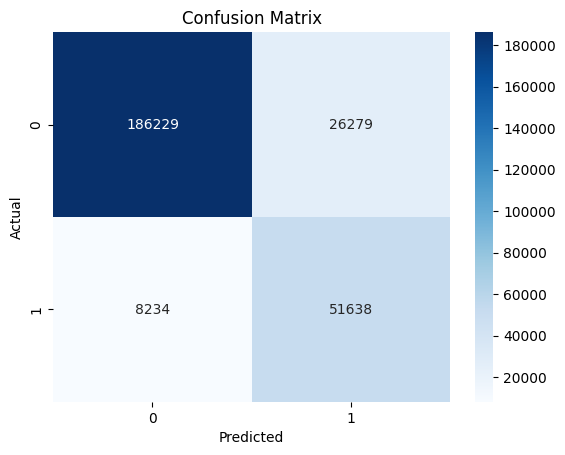

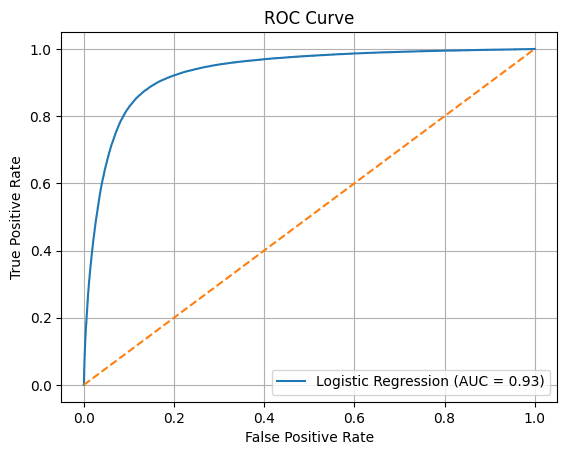

In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict probabilities and labels
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Evaluate
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label='Logistic Regression (AUC = {:.2f})'.format(roc_auc_score(y_test, y_pred_proba)))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# XGB Regressor

[0]	validation_0-auc:0.93207
[1]	validation_0-auc:0.93296
[2]	validation_0-auc:0.93385
[3]	validation_0-auc:0.93413
[4]	validation_0-auc:0.93426
[5]	validation_0-auc:0.93435


c:\Users\siddh\miniconda3\envs\tf\lib\site-packages\xgboost\core.py:158: UserWarning: [15:45:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[6]	validation_0-auc:0.93441
[7]	validation_0-auc:0.93444
[8]	validation_0-auc:0.93449
[9]	validation_0-auc:0.93460
[10]	validation_0-auc:0.93477
[11]	validation_0-auc:0.93479
[12]	validation_0-auc:0.93483
[13]	validation_0-auc:0.93491
[14]	validation_0-auc:0.93501
[15]	validation_0-auc:0.93514
[16]	validation_0-auc:0.93516
[17]	validation_0-auc:0.93530
[18]	validation_0-auc:0.93535
[19]	validation_0-auc:0.93537
[20]	validation_0-auc:0.93547
[21]	validation_0-auc:0.93553
[22]	validation_0-auc:0.93556
[23]	validation_0-auc:0.93559
[24]	validation_0-auc:0.93561
[25]	validation_0-auc:0.93569
[26]	validation_0-auc:0.93576
[27]	validation_0-auc:0.93581
[28]	validation_0-auc:0.93583
[29]	validation_0-auc:0.93590
[30]	validation_0-auc:0.93594
[31]	validation_0-auc:0.93598
[32]	validation_0-auc:0.93601
[33]	validation_0-auc:0.93604
[34]	validation_0-auc:0.93607
[35]	validation_0-auc:0.93611
[36]	validation_0-auc:0.93614
[37]	validation_0-auc:0.93619
[38]	validation_0-auc:0.93622
[39]	validatio

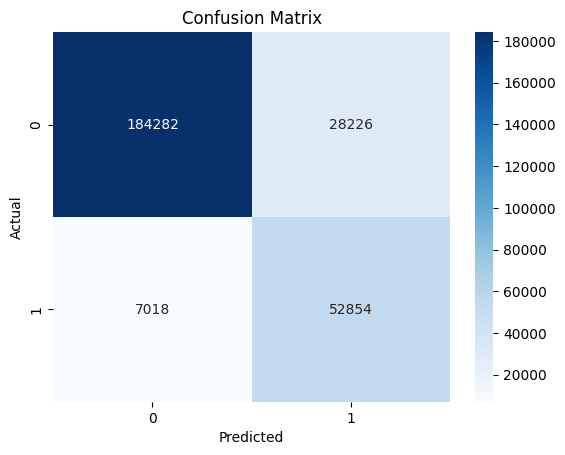

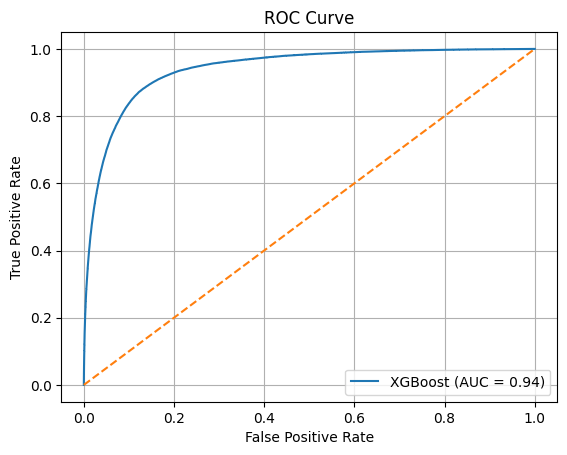

In [6]:
xgb_model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.045,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)

# Train with early stopping
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

# Predict probabilities and labels
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred = xgb_model.predict(X_test)

# Evaluate
print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label='XGBoost (AUC = {:.2f})'.format(roc_auc_score(y_test, y_pred_proba)))
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


## Model Comparison: Logistic Regression vs XGBoost
AUC-ROC: Logistic Regression = 0.9317, XGBoost = 0.9401

Accuracy: Both models achieve 0.87

Precision (Class 1): Logistic = 0.66, XGBoost = 0.65

Recall (Class 1): Logistic = 0.86, XGBoost = 0.88

F1-Score (Class 1): Both models = 0.75

### Why XGBoost Was Chosen
Logistic Regression performed slightly better on class 0 (non-defaulters), showing higher precision and fewer false positives.

XGBoost showed a slightly higher AUC-ROC, indicating stronger ranking ability.

It achieved a higher recall for default cases, capturing more true defaulters.

XGBoost can model non-linear relationships and interactions between features without manual engineering.

It is more robust to missing values and requires less preprocessing.

While logistic regression offers better interpretability, XGBoost provides superior predictive performance.

Considering minimizing financial loss is critical, XGBoost is better suited for identifying high-risk loans.

In [7]:
import joblib

joblib.dump(xgb_model, 'xgb_credit_model_final.pkl')
print("Model saved as xgb_credit_model.pkl")

joblib.dump(model, 'logistic_credit_model_final.pkl')
print("Model saved as logistic_credit_model.pkl")

Model saved as xgb_credit_model.pkl
Model saved as logistic_credit_model.pkl


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from scipy import stats as sps
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_on_holdout(model, X_test, y_test):
    # Predict classes and probabilities
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    # KS statistic
    mask = y_test.astype(bool)
    churn = y_pred_proba[mask]
    not_churn = y_pred_proba[~mask]
    ks = sps.ks_2samp(churn, not_churn)[0]

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    plot_confusion_matrix(conf_matrix)

    # Summary
    return {
        'accuracy': accuracy,
        'auc': auc,
        'ks': ks,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

def plot_confusion_matrix(conf_matrix, xtick_labels=['Good Loan', 'Bad Loan'], ytick_labels=['Good Loan', 'Bad Loan']):
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(conf_matrix.T, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 18})
    ax.set_xlabel('True Label')
    ax.set_ylabel('Predicted Label')
    ax.set_xticklabels(xtick_labels)
    ax.set_yticklabels(ytick_labels)
    plt.title("Confusion Matrix on Holdout Test Set")
    ax.axis('equal')
    plt.show()

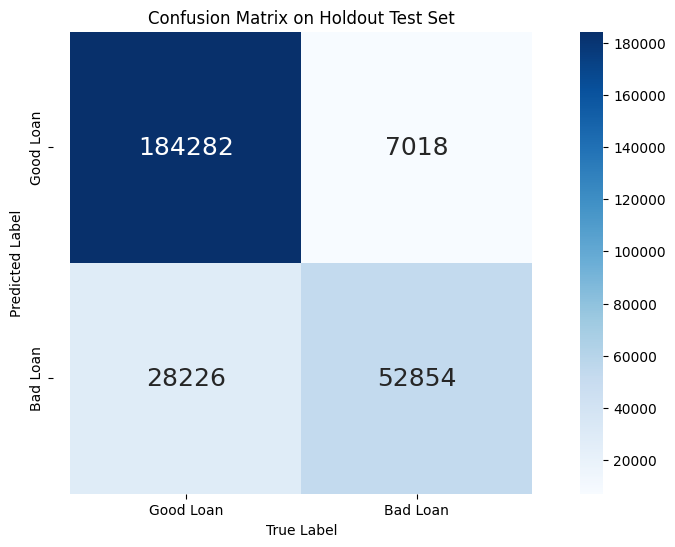

{'accuracy': 0.8706072398854542, 'auc': 0.9401151641854874, 'ks': 0.7502316321135108, 'precision': 0.6518746916625555, 'recall': 0.8827832709780866, 'f1': 0.7499574323173847}


In [ ]:
test_metrics = evaluate_on_holdout(xgb_model, X_test, y_test)
print(test_metrics)

In [11]:
y_test = y_test.values.ravel()

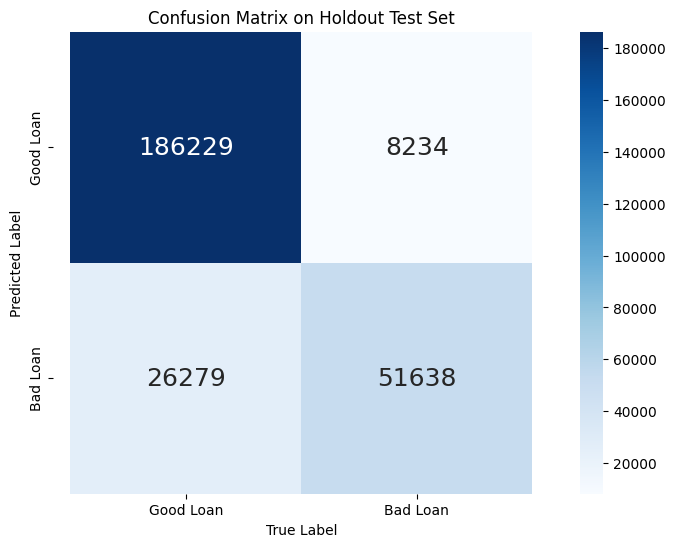

{'accuracy': 0.8732909905279389, 'auc': 0.9316714285963636, 'ks': 0.7404560819401151, 'precision': 0.6627308546273599, 'recall': 0.862473276322822, 'f1': 0.7495228211250535}


In [15]:
test_metrics = evaluate_on_holdout(model, X_test, y_test)
print(test_metrics)

## Threshold Tuning Based on Precision
Evaluated model performance across probability thresholds from 0.10 to 0.89

Computed precision at each threshold using precision_score

Plotted precision vs. threshold to visualize how stricter or looser thresholds affect false positives

Identified the first threshold where precision exceeds 0.75

This threshold is selected to balance accuracy and business risk tolerance

Final threshold can be used for loan approval decisions instead of the default 0.5

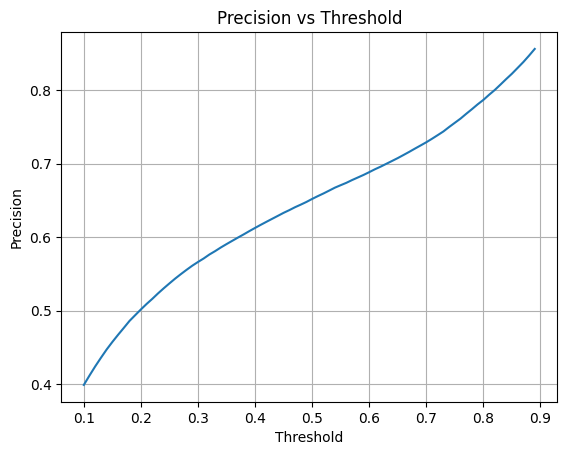

In [17]:
from sklearn.metrics import precision_score

# Predict probabilities
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Try different thresholds
thresholds = np.arange(0.1, 0.9, 0.01)
precisions = [precision_score(y_test, y_proba > t) for t in thresholds]

# Plot precision vs threshold
plt.plot(thresholds, precisions)
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.title('Precision vs Threshold')
plt.grid(True)
plt.show()

# Pick threshold where precision > 0.75
best_thresh = thresholds[np.argmax(np.array(precisions) > 0.75)]


In [18]:
best_thresh

0.7499999999999997

#### Final threshold = 0.749

In [ ]:
# # Ensure target is a Series and dtype is int (or float)
# train_y = y_train['target'] if isinstance(y_train, pd.DataFrame) else train_y
# test_y = y_test['target'] if isinstance(y_test, pd.DataFrame) else test_y

# y_train = train_y.astype(int)
# y_test = test_y.astype(int)


### LendingClub Financial Metrics Script Summary

- Cleans and validates raw LendingClub data, including interest rates, payments, and recoveries.
- Segregates loans into Fully Paid and Defaulted/Charged Off categories.
- Calculates:
  - Average and median profit per fully paid loan
  - Average and median loss per defaulted loan
  - Portfolio-level metrics such as total profit, total losses, and ROI
- Computes risk-adjusted metrics:
  - Expected loss and profit per loan
  - Default rate
- Analyzes loan performance by grade to highlight risk-return patterns.


In [33]:
import sys
sys.path.append("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/Scripts")

from calc_metrics import load_and_analyze_lending_club_data

In [34]:
file_path = 'C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/raw/data/raw/accepted_2007_to_2018Q4.csv'

metrics = load_and_analyze_lending_club_data(file_path)

# Optional: set in your optimizer
optimizer.avg_loss_per_default = metrics['avg_loss_per_default']
optimizer.avg_profit_per_loan = metrics['avg_profit_per_loan']

Loading data from: C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/data/raw/data/raw/accepted_2007_to_2018Q4.csv
Successfully loaded 2260701 rows
Columns: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fi

### LendingClub Portfolio Summary (2007–2018)

### Dataset Overview
- Total loans analyzed: 2,260,668
- Fully Paid loans: 1,076,751 (47.6%)
- Charged Off / Defaulted loans: 268,599 (11.9%)

### Profit Analysis (Fully Paid Loans)
- Average profit per fully paid loan: $2,318.87
- Median profit per fully paid loan: $1,518.10
- Average expected interest: $3,842.94
- Average actual interest earned: $2,318.87

### Loss Analysis (Charged Off Loans)
- Average loss per default: $6,266.00
- Median loss per default: $4,977.02
- Average gross loss (before recoveries): $7,273.79
- Average recoveries: $1,209.28
- Recovery rate: 16.6%

### Portfolio-Level Metrics
- Total loan amount: $34.02 Billion
- Total payments received: $27.31 Billion
- Total profit from good loans: $2.50 Billion
- Total losses from bad loans: $1.68 Billion
- Net portfolio return: $813.81 Million
- Portfolio ROI: 2.39%

### Risk-Adjusted Per-Loan Metrics
- Default rate: 11.88%
- Expected loss per loan: $744.49
- Expected profit per loan: $2,043.36
- Expected net profit per loan: $1,298.87

### Loan Grade Breakdown (Defaults Rise with Risk)
- Grade A: Default rate 3.3%, Avg interest 7.1%
- Grade B: Default rate 7.9%, Avg interest 10.7%
- Grade C: Default rate 13.2%, Avg interest 14.1%
- Grade D: Default rate 18.8%, Avg interest 18.1%
- Grade E: Default rate 26.6%, Avg interest 21.8%
- Grade F: Default rate 34.7%, Avg interest 25.5%
- Grade G: Default rate 37.5%, Avg interest 28.1%


# Credit Optimizer

### What the `CreditRiskOptimizer` Class Does

- Evaluates and optimizes classification thresholds for credit risk
- Calculates business-specific metrics:
  - Net benefit
  - Approval rate
  - Gained profits
  - Lost profits
  - Actual losses
- Supports 4 threshold optimization strategies:
  - Expected value maximization (maximize net benefit)
  - F-beta score optimization (balance precision and recall)
  - Profit-based scenario simulation (conservative, balanced, aggressive)
  - Segment-wise optimization (low/medium/high-risk borrower groups)
- Allows customization of business parameters:
  - `avg_loss_per_default`
  - `avg_profit_per_loan`
  - `interest_rate`
- Includes visualizations:
  - Net Benefit vs Threshold
  - Precision–Recall Tradeoff
  - Approval Rate vs Threshold
  - Breakdown of profit/loss components
- Returns all results in a dictionary for easy reporting or further analysis

In [21]:
import sys
sys.path.append("C:/Users/siddh/AppData/Local/Microsoft/WindowsApps/files/credit-risk-optimization/credit-risk-optimization/Scripts")

from credit_optimizer import CreditRiskOptimizer


Credit Risk Optimizer created!

To use this with your XGBoost model:
1. Get predicted probabilities: y_pred_proba = model.predict_proba(X_test)[:, 1]
2. Create optimizer: optimizer = CreditRiskOptimizer(y_true, y_pred_proba)
3. Run analysis: results = optimizer.run_complete_analysis()

You can also customize business parameters:
- optimizer.avg_loss_per_default = 50000
- optimizer.avg_profit_per_loan = 5000


CREDIT RISK THRESHOLD OPTIMIZATION
=== EXPECTED VALUE ANALYSIS ===
Optimal Threshold: 0.550
Maximum Net Benefit: $651,123,056
Precision: 0.671
Recall: 0.869
Approval Rate: 0.715

=== F-BETA SCORE ANALYSIS ===
Beta = 0.5 (recall weight = 0.5, precision weight = 1)
  Best Threshold: 0.850
  F-beta Score: 0.779
  Precision: 0.822, Recall: 0.644
  Net Benefit: $562,352,966

Beta = 1.0 (recall weight = 1.0, precision weight = 1)
  Best Threshold: 0.700
  F-beta Score: 0.765
  Precision: 0.729, Recall: 0.805
  Net Benefit: $638,504,445

Beta = 1.5 (recall weight = 1.5, precision weight = 1)
  Best Threshold: 0.550
  F-beta Score: 0.796
  Precision: 0.671, Recall: 0.869
  Net Benefit: $651,123,056

Beta = 2.0 (recall weight = 2.0, precision weight = 1)
  Best Threshold: 0.400
  F-beta Score: 0.827
  Precision: 0.612, Recall: 0.907
  Net Benefit: $638,637,408

=== PROFIT-BASED OPTIMIZATION ===
Conservative (High Loss Aversion):
  Loss per default: $100,000
  Profit per loan: $3,000
  Optimal t

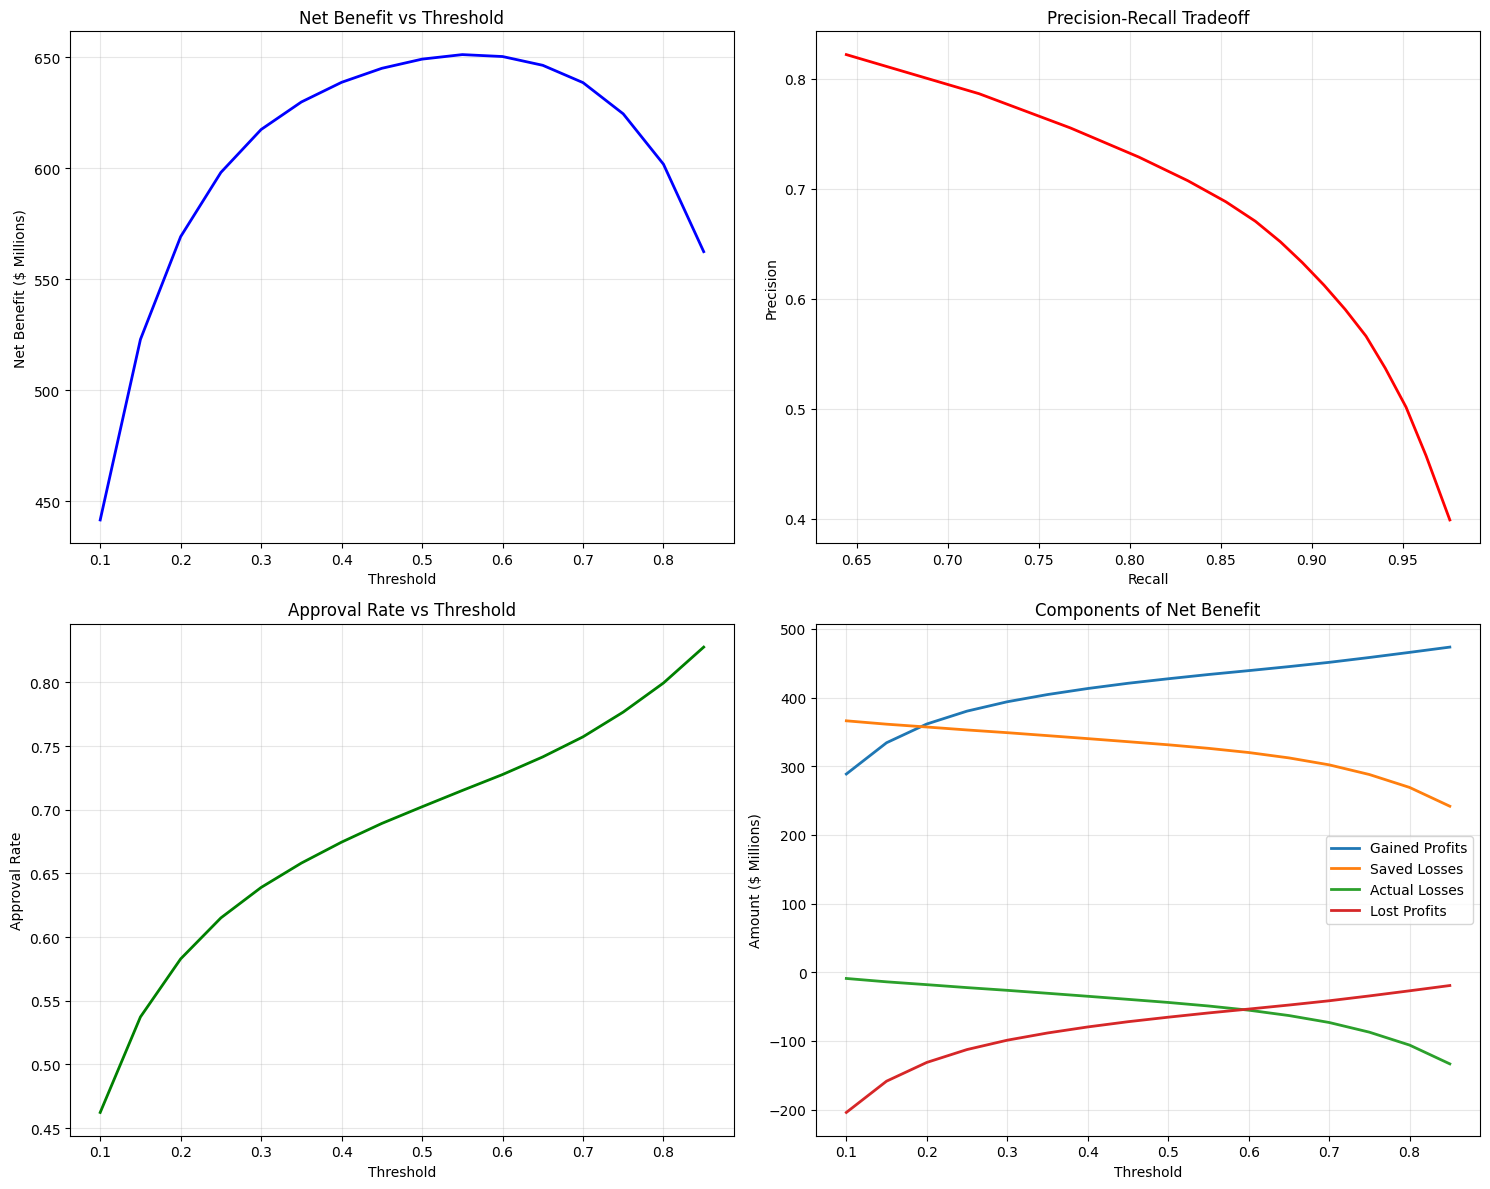

In [22]:
y_pred_proba = y_proba

optimizer = CreditRiskOptimizer(y_test, y_pred_proba)
optimizer.avg_loss_per_default = 6266.00  #actual loss
optimizer.avg_profit_per_loan = 2318.87    #actual profit
results = optimizer.run_complete_analysis()

### Credit Risk Threshold Optimization Summary

- **Expected Value Optimization**
  - Optimal Threshold: **0.550**
  - Precision: 0.671, Recall: 0.869
  - Net Benefit: **$651M**
  - Approval Rate: 71.5%

- **F-Beta Score Optimization**
  - β = 0.5 → Threshold: 0.850 → Precision: 0.822, Recall: 0.644 → Net Benefit: $562M
  - β = 1.0 → Threshold: 0.700 → Precision: 0.729, Recall: 0.805 → Net Benefit: $638M
  - β = 1.5 → Threshold: 0.550 → Precision: 0.671, Recall: 0.869 → Net Benefit: $651M
  - β = 2.0 → Threshold: 0.400 → Precision: 0.612, Recall: 0.907 → Net Benefit: $639M

- **Profit-Based Strategy Simulation**
  - Conservative: Threshold = 0.100 → Net Benefit = **$5.81B** → Recall = 0.976, Precision = 0.399
  - Balanced: Threshold = 0.250 → Net Benefit = **$3.21B** → Recall = 0.940, Precision = 0.537
  - Aggressive: Threshold = 0.500 → Net Benefit = **$2.62B** → Recall = 0.883, Precision = 0.652

- **Segment-Based Optimization (by PD Quartiles)**
  - **Low Risk** (0.5% default): Threshold = 0.000 → Recall = 1.000 → Net Benefit = -∞ (over-approves)
  - **Medium-Low Risk** (2.2% default): Threshold = 0.100 → Net Benefit = $104M
  - **Medium-High Risk** (13.3% default): Threshold = 0.550 → Net Benefit = $89M
  - **High Risk** (71.9% default): Threshold = 0.700 → Precision = 0.729, Recall = 0.984 → Net Benefit = $258M


In [39]:
expected_df = results['expected_value']
expected_df.to_csv("expected_prof_df.csv")

In [25]:
# Set custom threshold
threshold = 0.55
y_pred_custom = (y_proba >= threshold).astype(int)

print(f"\n[INFO] Evaluation at threshold = {threshold}")
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))  # AUC stays the same
print("Classification Report:\n", classification_report(y_test, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))



[INFO] Evaluation at threshold = 0.55
ROC-AUC Score: 0.9401151641854874
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.88      0.92    212508
           1       0.67      0.87      0.76     59872

    accuracy                           0.88    272380
   macro avg       0.82      0.87      0.84    272380
weighted avg       0.90      0.88      0.88    272380

Confusion Matrix:
 [[186946  25562]
 [  7841  52031]]


#### Model Evaluation at Optimal Threshold = 0.550

- **ROC-AUC Score**: 0.9401
- **Accuracy**: 88.0%
- **Precision (Class 1 - Default)**: 0.67
- **Recall (Class 1 - Default)**: 0.87
- **F1-Score (Class 1)**: 0.76

- **Confusion Matrix**:
  - True Negatives (TN): 186,946
  - False Positives (FP): 25,562
  - False Negatives (FN): 7,841
  - True Positives (TP): 52,031

- **Interpretation**:
  - High recall indicates strong ability to catch defaulters.
  - Precision is reasonable, controlling false positives.
  - Balanced trade-off makes this threshold suitable for risk-sensitive lending strategies.


In [27]:
threshold = 0.749
y_pred_custom = (y_proba >= threshold).astype(int)

print(f"\n[INFO] Evaluation at threshold = {threshold}")
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))  # AUC stays the same
print("Classification Report:\n", classification_report(y_test, y_pred_custom))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_custom))


[INFO] Evaluation at threshold = 0.749
ROC-AUC Score: 0.9401151641854874
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93    212508
           1       0.75      0.77      0.76     59872

    accuracy                           0.89    272380
   macro avg       0.84      0.85      0.85    272380
weighted avg       0.89      0.89      0.89    272380

Confusion Matrix:
 [[197567  14941]
 [ 13869  46003]]


#### Model Evaluation at High-Precision Threshold = 0.749

- **ROC-AUC Score**: 0.9401  
- **Accuracy**: 89.0%
- **Precision (Class 1 - Default)**: 0.75  
- **Recall (Class 1 - Default)**: 0.77  
- **F1-Score (Class 1)**: 0.76  

- **Confusion Matrix**:
  - True Negatives (TN): 197,567  
  - False Positives (FP): 14,941  
  - False Negatives (FN): 13,869  
  - True Positives (TP): 46,003  

- **Interpretation**:
  - Precision is high (0.75), reducing false positives significantly.
  - However, this comes at the cost of **lower recall** and **fewer approved loans**.
  - As a result, total profit is lower due to **missed good loans** and **unrecovered default losses**.
  - This threshold may be suitable when minimizing **false approvals** is the top priority (e.g., highly risk-averse policy).


# SHAP
- SHapley Additive exPlanations.
- Explains how each feature contributes to model predictions.
- `summary_plot`: shows global feature importance and value impact.
- `plot_type="bar"`: gives a simplified feature importance ranking.
- `force_plot`: visualizes how features affect a single prediction.
- Useful for model transparency, regulatory compliance, and trust in credit decisions.

100%|===================| 272264/272380 [35:38<00:00]        

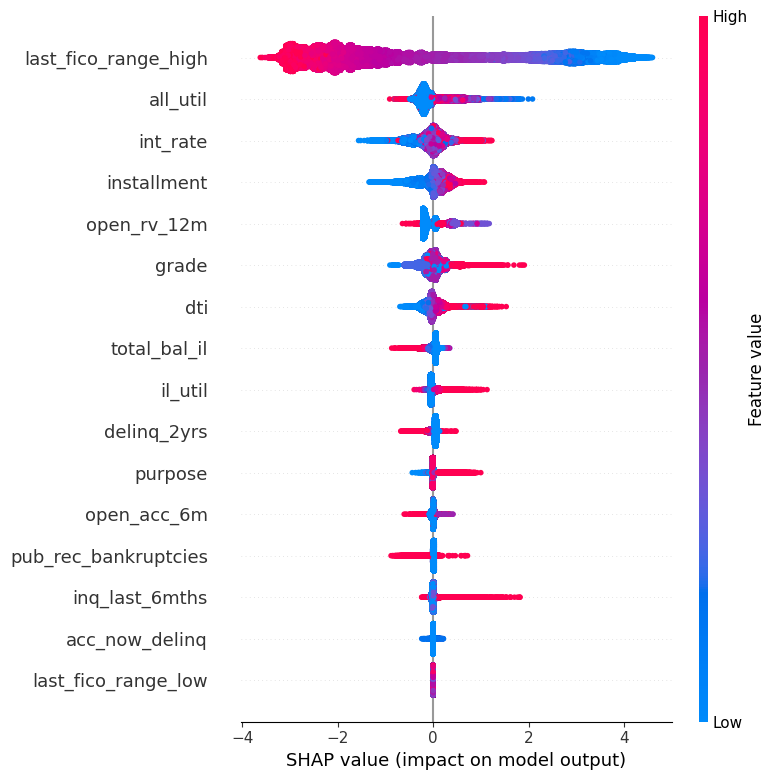

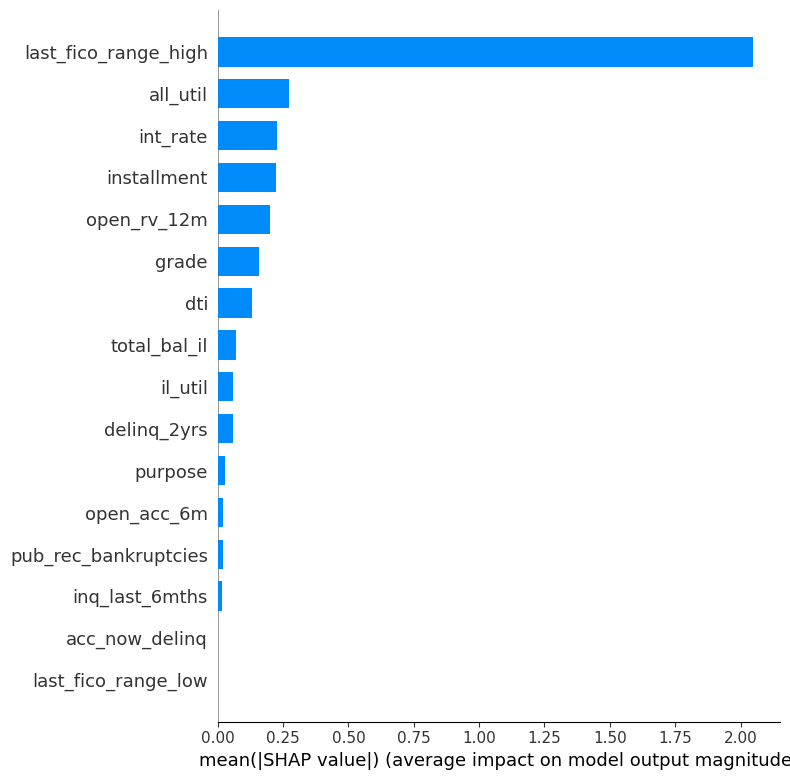

In [35]:
import shap
import xgboost as xgb

# 1. Create SHAP explainer
explainer = shap.Explainer(xgb_model, X_test)

# 2. Calculate SHAP values
shap_values = explainer(X_test)

# 3. Summary plot (global feature importance)
shap.summary_plot(shap_values, X_test)

# 4. Bar plot version (easier to interpret sometimes)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# 5. Force plot for individual prediction (e.g., index 0)
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0].values, X_test.iloc[0])

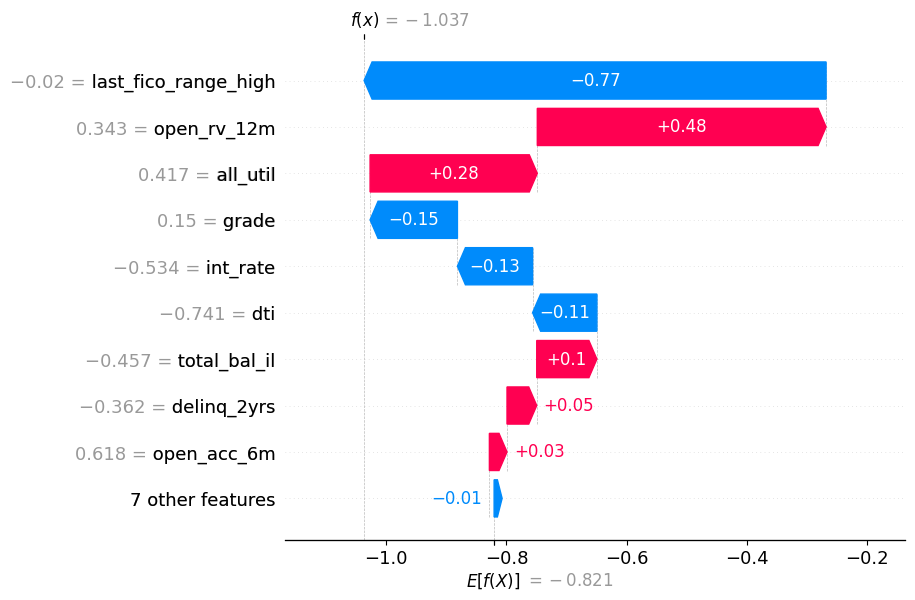

In [36]:
shap.plots.waterfall(shap_values[0])

### SHAP Summary Plot: Feature Importance for Default Prediction

This SHAP (SHapley Additive exPlanations) plot visualizes how each feature influences the model's output (i.e., probability of default).

- **Y-axis**: Top 15 most impactful features ranked by average absolute SHAP value.
- **X-axis**: SHAP value – how much a feature contributes to increasing or decreasing default risk.
- **Color Gradient**:  
  - **Red** = High feature value  
  - **Blue** = Low feature value

#### Key Interpretations:

- **`last_fico_range_high`**: Most important feature. High FICO scores (blue) strongly reduce predicted default probability.
- **`int_rate`**: Higher interest rates (red) increase default risk, consistent with creditworthiness signals.
- **`installment`, `dti`, `il_util`**: Higher debt-related features typically increase default risk.
- **`grade`**: Internal LendingClub rating—strongly influences model predictions.
- **`delinq_2yrs`, `pub_rec_bankruptcies`**: Historical delinquency and bankruptcy records positively contribute to default predictions.

This plot provides a transparent view of how borrower characteristics impact the model, useful for internal validation and regulatory explainability (e.g., aligning with **Basel III/IV** principles).

---